In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

import medmnist
from medmnist import INFO


## Extracting the data from the dataset
Loads MedMNIST data into variables

In [3]:
dataset = "breastmnist"

info = INFO[dataset]
task = info["task"]
n_channels = info['n_channels']
n_classes = len(info['label'])

# Load training and test data using the local folder
DataClass = getattr(medmnist, info["python_class"])
train_dataset = DataClass(split="train", download=False)
val_dataset = DataClass(split="val", download=False)
test_dataset = DataClass(split="test", download=False)

Dataset BreastMNIST of size 28 (breastmnist)
    Number of datapoints: 546
    Root location: C:\Users\Alvin\.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'malignant', '1': 'normal, benign'}
    Number of samples: {'train': 546, 'val': 78, 'test': 156}
    Description: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
    License: CC BY 4.0


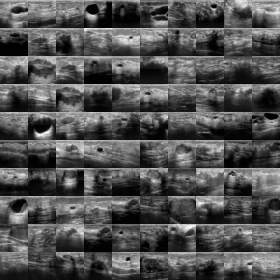

In [3]:
print(train_dataset)
train_dataset.montage(10)

## Using only flattened Image for input into SVM


In [4]:
# extract all the labels and images from the dataset
# all the pixel values are also divided by 255 to keep them between 0 and 1, as SVMs are not scale invariant

train_images = np.array(train_dataset.imgs)
train_images_flat = np.array([train_images[i,:].flatten() for i in range(train_images.shape[0])])/255

val_images = np.array(val_dataset.imgs)
val_images_flat = np.array([val_images[i,:].flatten() for i in range(val_images.shape[0])])/255

test_images = np.array(test_dataset.imgs)
test_images_flat = np.array([test_images[i,:].flatten() for i in range(test_images.shape[0])])/255

train_labels = np.array(train_dataset.labels).flatten()
val_labels = np.array(val_dataset.labels).flatten()
test_labels = np.array(test_dataset.labels).flatten()

In [5]:
clf = svm.SVC()
clf.fit(train_images_flat, train_labels)

val_accuracy = clf.score(val_images_flat, val_labels)
print(val_accuracy)

0.8205128205128205


0.7948717948717948


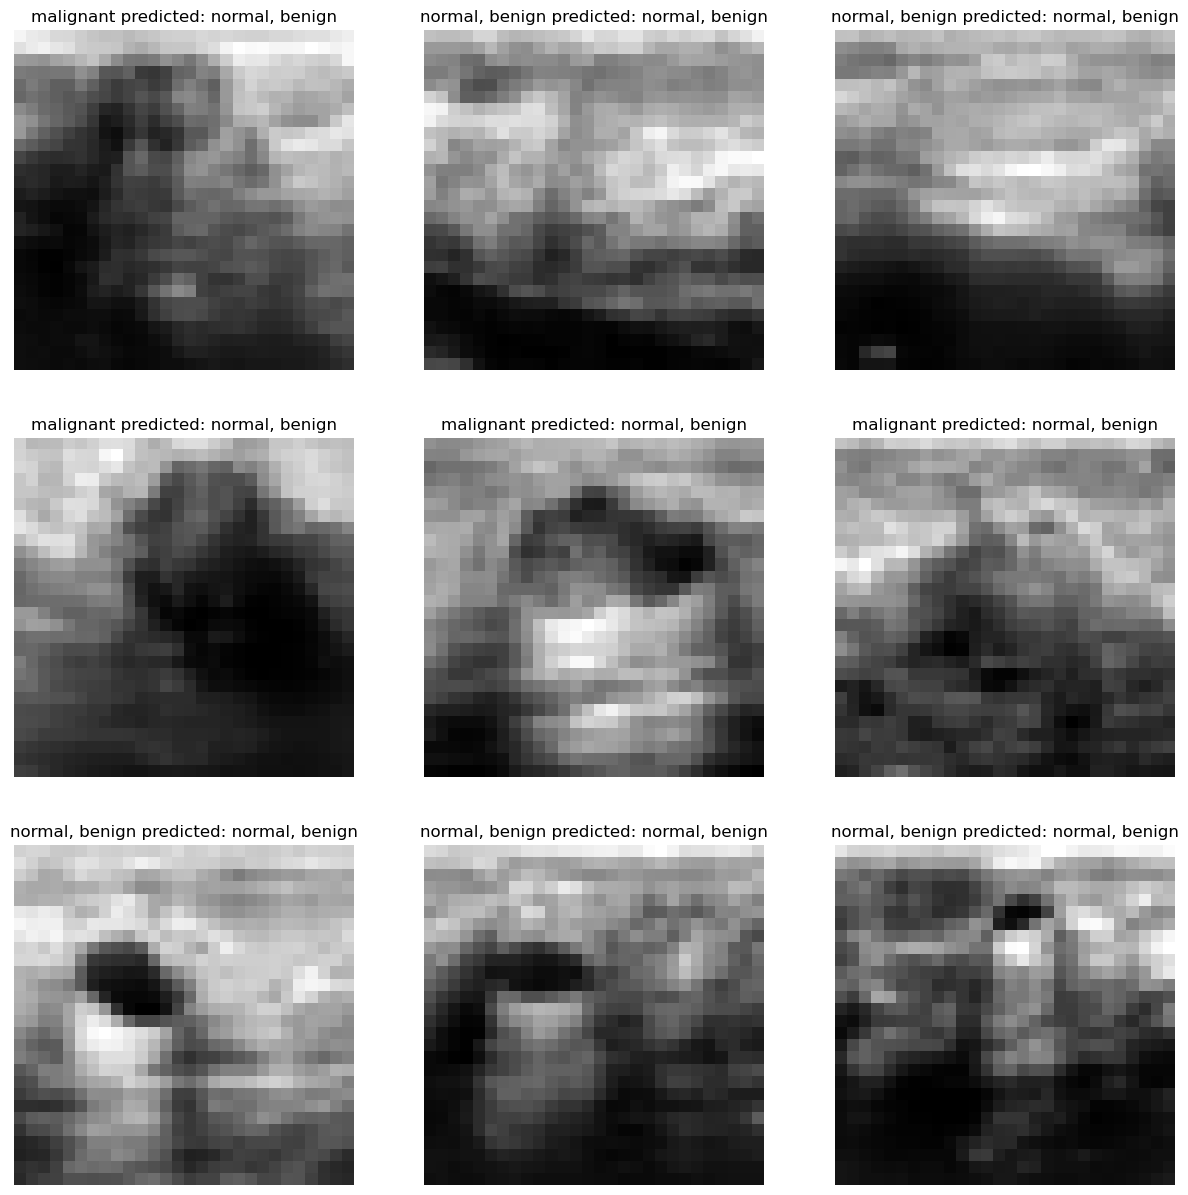

In [6]:
import random 

labels_map = {
    0: "malignant",
    1: "normal, benign"
}

figure = plt.figure(figsize=(15, 15))

for i in range(1, 9 + 1):
    sample_id = random.randint(0, test_images.shape[0])
    image = test_images[sample_id]
    label = test_labels[sample_id]
    flat_image = test_images_flat[sample_id].reshape(1,-1)
    prediction = clf.predict(flat_image).item()

    figure.add_subplot(3, 3, i)
    plt.title(f"{labels_map[label]} predicted: {labels_map[prediction]}")
    plt.axis("off")
    plt.imshow(image.squeeze(), cmap="gray")

plt.show

test_accuracy = clf.score(test_images_flat, test_labels)
print(test_accuracy)

Experimenting with different kernels

Talk about the converging issue with linearSVC

In [20]:
C = 1

models = (svm.SVC(kernel='linear', C=C),
          svm.LinearSVC(C=0.1),
          svm.SVC(kernel='rbf', gamma=0.7, C=C),
          svm.SVC(kernel='poly', degree=3, C=C))

names = ('SVC with linear kernel',
         'LinearSVC (linear kernel)',
         'SVC with RBF kernel',
         'SVC with polynomial (degree 3) kernel')

models = (classifier.fit(train_images_flat, train_labels) for classifier in models)

for classifier, name in zip(models, names):
    val_accuracy = classifier.score(val_images_flat, val_labels)
    print(f"{name} validation accuracy: {val_accuracy}")

SVC with linear kernel validation accuracy: 0.8461538461538461
LinearSVC (linear kernel) validation accuracy: 0.8333333333333334
SVC with RBF kernel validation accuracy: 0.7692307692307693
SVC with polynomial (degree 3) kernel validation accuracy: 0.8461538461538461


## Now with feature extraction

While the accuracy is quite good, the large dimensionality of the dataset means the computation required is quite high.

Different methods of feature extraction is explored

In [46]:
from skimage.feature import hog


def extract_hog_feats(images):
    features = []

    for image in images:
        fd = hog(
            image,
            orientations=8,
            pixels_per_cell=(4, 4),
            cells_per_block=(1, 1),
            visualize=False,
            channel_axis=None,
        )

        features.append(fd)

    features = np.array(features)

    return features

train_features = extract_hog_feats(train_images)

feat_clf = svm.SVC()
feat_clf.fit(train_features, train_labels)

val_features = extract_hog_feats(val_images)
feat_val_accuracy = feat_clf.score(val_features, val_labels)
print(feat_val_accuracy)
 

0.8205128205128205


0.7756410256410257


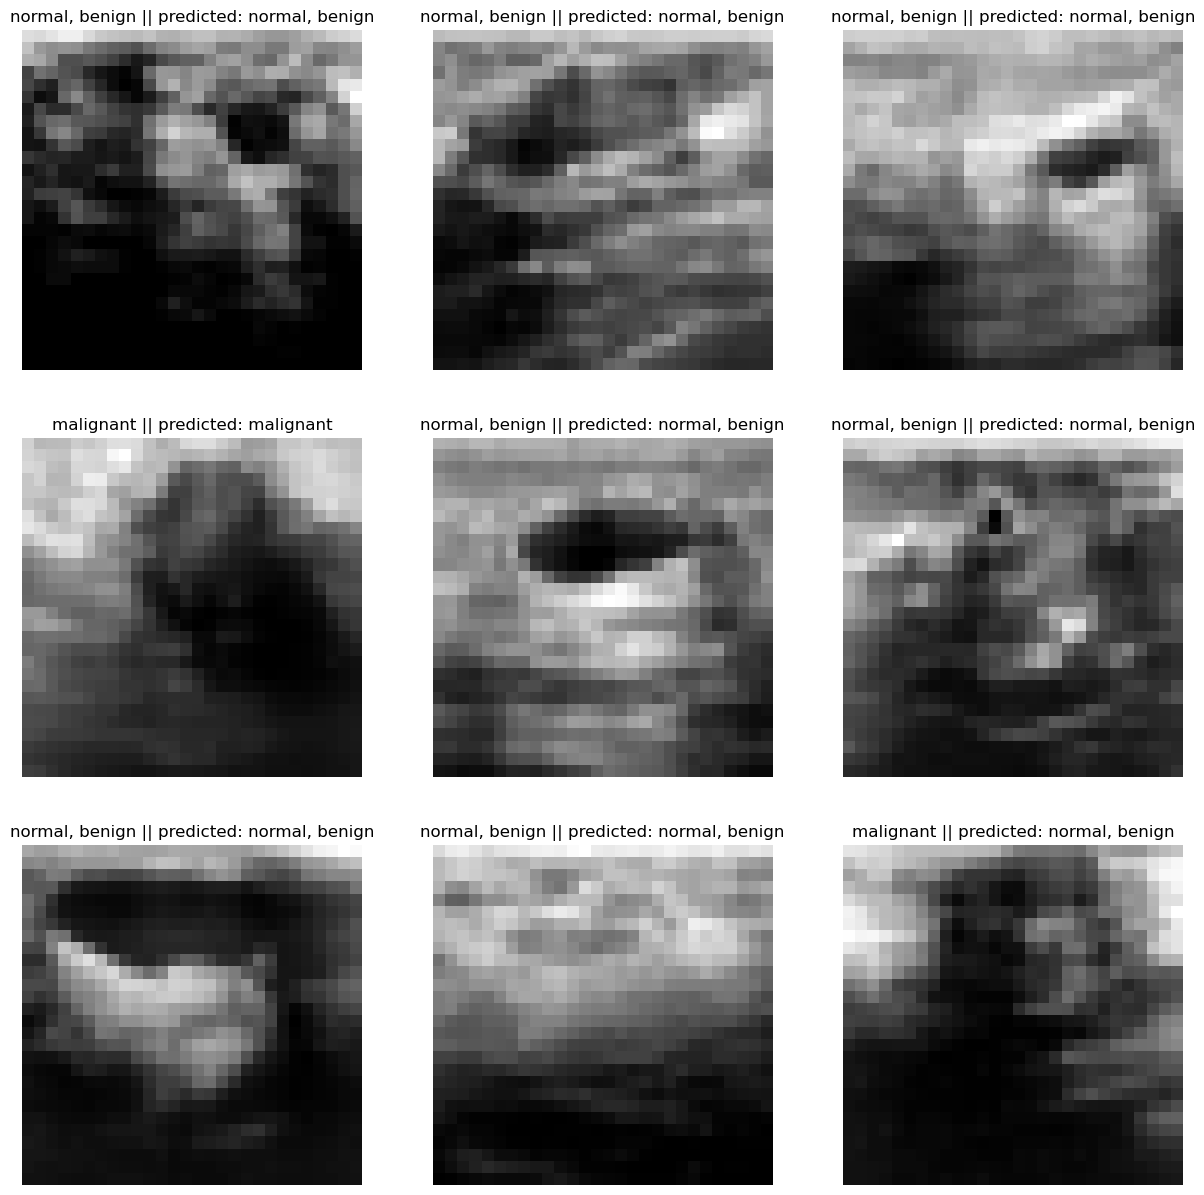

In [23]:
figure2 = plt.figure(figsize=(15, 15))

for i in range(1, 9 + 1):
    sample_id = random.randint(0, test_images.shape[0])
    image = test_images[sample_id]
    label = test_labels[sample_id]
    
    fd= hog(
            image,
            orientations=8,
            pixels_per_cell=(4, 4),
            cells_per_block=(1, 1),
            visualize=False,
            channel_axis=None,
        )

    prediction = feat_clf.predict(fd.reshape(1, -1)).item()

    figure2.add_subplot(3, 3, i)
    plt.title(f"{labels_map[label]} || predicted: {labels_map[prediction]}")
    plt.axis("off")
    plt.imshow(image.squeeze(), cmap="gray")

plt.show

test_features = extract_hog_feats(test_images)

test_accuracy = feat_clf.score(test_features, test_labels)
print(test_accuracy)

In [47]:
C = 0.8

models = (svm.SVC(kernel='linear', C=C),
          svm.LinearSVC(C=C),
          svm.SVC(kernel='rbf', gamma=0.7, C=C),
          svm.SVC(kernel='poly', degree=3, C=C))

names = ('SVC with linear kernel',
         'LinearSVC (linear kernel)',
         'SVC with RBF kernel',
         'SVC with polynomial (degree 3) kernel')


train_features = extract_hog_feats(train_images)

models = (classifier.fit(train_features, train_labels) for classifier in models)

val_features = extract_hog_feats(val_images)

for classifier, name in zip(models, names):
    val_accuracy = classifier.score(val_features, val_labels)
    print(f"{name} validation accuracy: {val_accuracy}")

SVC with linear kernel validation accuracy: 0.7948717948717948
LinearSVC (linear kernel) validation accuracy: 0.7435897435897436
SVC with RBF kernel validation accuracy: 0.7307692307692307
SVC with polynomial (degree 3) kernel validation accuracy: 0.8076923076923077


## Experimenting with convolutional filters

Convolutional filters to extract features from an image

In [49]:
import torch
from torchvision import models
from torchvision import transforms
from torch import nn
import torch.utils.data as data

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [50]:
# Data transformations, turn into tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform, download=False)
val_dataset = DataClass(split="val", transform=transform, download=False)
test_dataset = DataClass(split="test", transform=transform, download=False)

train_loader = data.DataLoader(dataset=train_dataset, batch_size=len(train_dataset), shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=len(val_dataset), shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=len(test_dataset), shuffle=False)

Load the pretrained model

Replace the fully connected layer with an identity layer, effectively removing it

Change the input layer into 1 channel as the input image is grayscale

In [51]:
# Use pretrained model for convolution filters, first no training is done to evaluate the filters' ability to extract features
cnn_model = models.resnet18(weights="DEFAULT")
# Remove the classification layer
cnn_model.fc = nn.Identity()
# convert the input layer to only have 1 channel as the images are grayscale
cnn_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3,
                               bias=False)

cnn_model = cnn_model.to(device)

Input the image into the CNN and use the output from the convoluton layers into the SVM and train

In [52]:
def extract_conv_features(data):
    cnn_model.eval()

    with torch.no_grad():
        for inputs, labels in data:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = cnn_model(inputs)

    return outputs.cpu().numpy()

conv_train_features = extract_conv_features(train_loader)


In [53]:
conv_clf = svm.SVC()
conv_clf.fit(conv_train_features, train_labels)

conv_val_features = extract_conv_features(val_loader)

val_accuracy = conv_clf.score(conv_val_features, val_labels)
print(val_accuracy)


0.7307692307692307


0.7307692307692307


<function matplotlib.pyplot.show(close=None, block=None)>

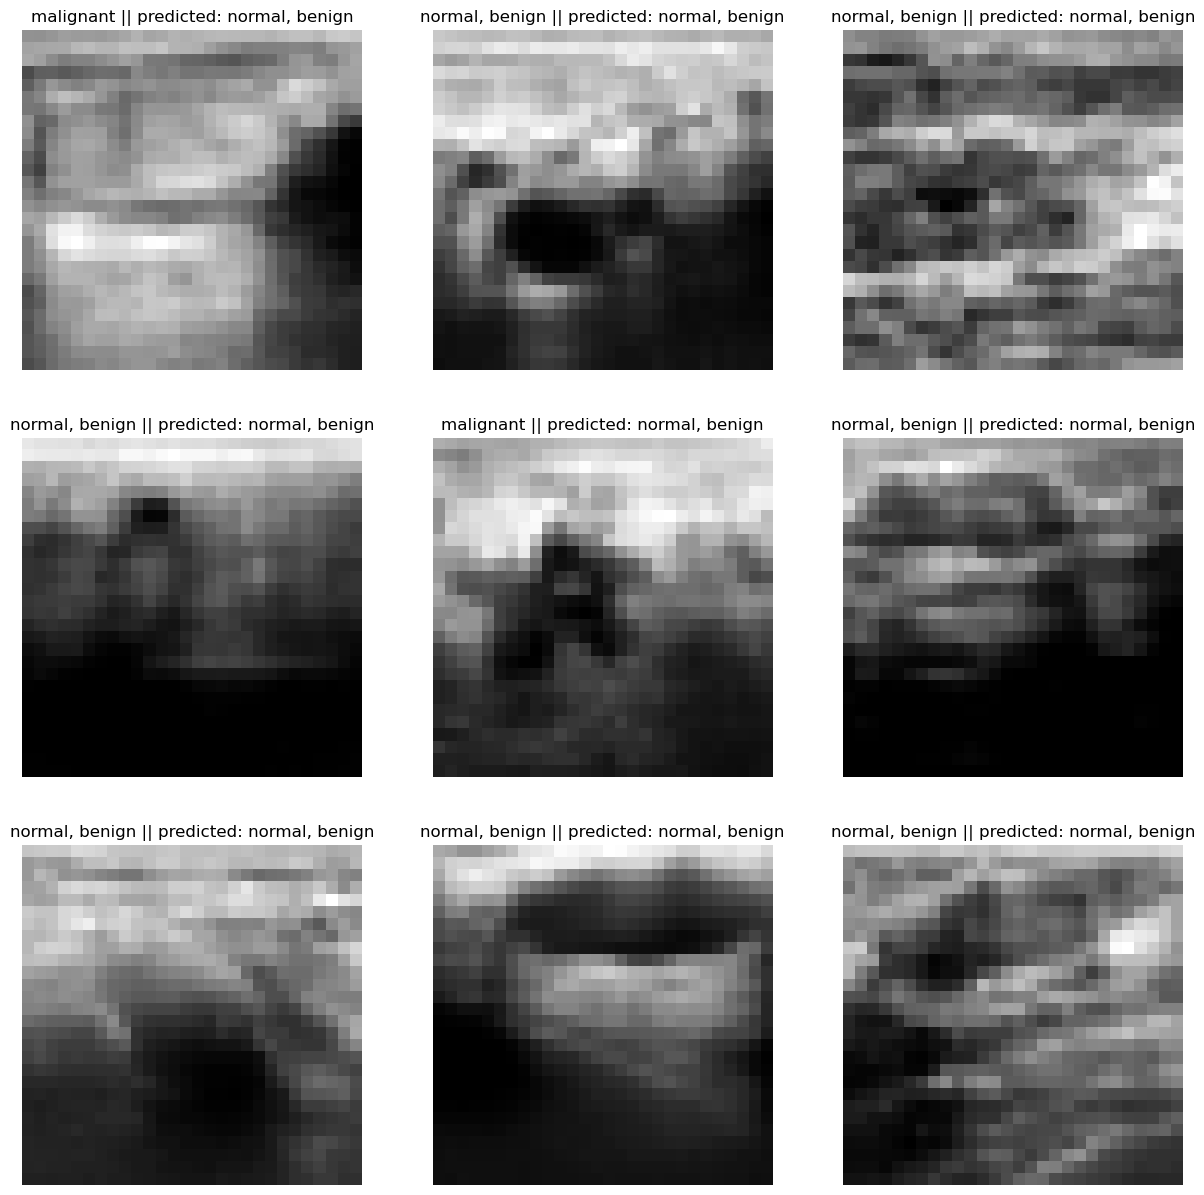

In [55]:
conv_test_features = extract_conv_features(test_loader)

test_accuracy = conv_clf.score(conv_test_features, test_labels)
print(test_accuracy)

figure3 = plt.figure(figsize=(15, 15))

for i in range(1, 9 + 1):
    sample_id = random.randint(0, test_images.shape[0])
    image = test_images[sample_id]
    label = test_labels[sample_id]

    test_data = transform(image).unsqueeze(0)
    cnn_model.eval()

    with torch.no_grad():
        test_data = test_data.to(device)
        output = cnn_model(test_data)
        output = output.cpu().numpy()

    prediction = conv_clf.predict(output).item()

    figure3.add_subplot(3, 3, i)
    plt.title(f"{labels_map[label]} || predicted: {labels_map[prediction]}")
    plt.axis("off")
    plt.imshow(image.squeeze(), cmap="gray")
    
plt.show


## PCA

In [83]:
from sklearn.decomposition import PCA

pca = PCA(n_components=28)

conv_train_features = extract_conv_features(train_loader)
pca_conv_train_features = pca.fit_transform(conv_train_features)

conv_val_features = extract_conv_features(val_loader)
pca_conv_val_features = pca.fit_transform(conv_val_features)

conv_test_features = extract_conv_features(test_loader)
pca_conv_test_features = pca.fit_transform(conv_test_features)

In [84]:
pca_conv_clf = svm.SVC()
pca_conv_clf.fit(pca_conv_train_features, train_labels)

val_accuracy = pca_conv_clf.score(pca_conv_val_features, val_labels)
print(val_accuracy)

0.7307692307692307


Experimenting with Kernels

In [69]:
C = 0.5

models = (svm.SVC(kernel='linear', C=C),
          svm.LinearSVC(C=0.1),
          svm.SVC(kernel='rbf', gamma=0.7, C=C),
          svm.SVC(kernel='poly', degree=3, C=C))

names = ('SVC with linear kernel',
         'LinearSVC (linear kernel)',
         'SVC with RBF kernel',
         'SVC with polynomial (degree 3) kernel')

conv_train_features = extract_conv_features(train_loader)

models = (classifier.fit(conv_train_features, train_labels) for classifier in models)

conv_val_features = extract_conv_features(val_loader)

for classifier, name in zip(models, names):
    val_accuracy = classifier.score(conv_val_features, val_labels)
    print(f"{name} validation accuracy: {val_accuracy}")

SVC with linear kernel validation accuracy: 0.7307692307692307
LinearSVC (linear kernel) validation accuracy: 0.7307692307692307
SVC with RBF kernel validation accuracy: 0.7307692307692307
SVC with polynomial (degree 3) kernel validation accuracy: 0.7307692307692307
